# Datavalidation

The Data has been created for 16.000 Buildings via a highly customized version of [TSIB](https://github.com/NV717/tsorb_simuflex). Before any further proceedings the validity of the generated data itself and its distribution is checked.

## ToDo

1. Check all runs completed/ which failed
2. Check generated results have same parameters as manifest and distribution
3. check timeseries for missing values/negative values/ problems and if distribution makes sense
4. check for identical timeseries

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize
import ast
from itertools import chain
from collections import Counter
from DataPreparationHelper import *
from tqdm import tqdm

RESULTS_DIR = Path(r"Generation/#Archive/Generation")
PLANNED_MANIFEST_PATH = r"manifest_planned.parquet"
REALIZED_MANIFEST_PATH = r"manifest_realised.parquet"

In [2]:
# realized_manifest = get_realized_manifest(RESULTS_DIR)
# realized_manifest.to_parquet(r"manifest_realised.parquet")

In [3]:
planned_manifest = pd.read_parquet(PLANNED_MANIFEST_PATH)
realized_manifest = pd.read_parquet(REALIZED_MANIFEST_PATH)

In [4]:
realized_manifest =clean_list_cols(realized_manifest,planned_manifest)

In [5]:
realized_manifest=realized_manifest.sort_values(by=["seed"]).reset_index(drop=True)


In [6]:
realized_manifest

,country,buildingType,surrounding,buildingAgeBin,a_ref,n_apartments,year_type,future,climateRegion,n_persons,...,state_seed,apartment_seeds,appliances,maxLoadViolation_kW,runtime_seconds,resolved_year,n_persons_sum,appliances_unique,building_id,run_id
0,DE,AB,Terraced,DE.02,1340.9,14,average,True,5,"[2, 2, 1, 4, 1, 1, 2, 1, 3, 3, 1, 4, 1, 2]",...,1000000,"[1341242, 2161857, 7980730, 3141875, 8938643, ...","[[UPRIGHT_FREEZER, ANSWER_MACHINE, CD_PLAYER, ...",6.166263e-11,492.192459,2018,28,"[UPRIGHT_FREEZER, ANSWER_MACHINE, CD_PLAYER, C...",0,run_000000
1,DE,AB,Terraced,DE.02,1340.9,14,average,True,5,"[2, 2, 1, 4, 1, 1, 2, 1, 3, 3, 1, 4, 1, 2]",...,1000001,"[7816614, 6767105, 9804180, 7763681, 9544759, ...","[[FRIDGE_FREEZER, FRIDGE, ANSWER_MACHINE, CD_P...",9.397497e-14,507.807770,2021,28,"[FRIDGE_FREEZER, FRIDGE, ANSWER_MACHINE, CD_PL...",0,run_000001
2,DE,AB,Terraced,DE.02,1340.9,14,average,True,5,"[2, 2, 1, 4, 1, 1, 2, 1, 3, 3, 1, 4, 1, 2]",...,1000002,"[5393235, 3905184, 5287101, 2391082, 5770489, ...","[[FRIDGE, ANSWER_MACHINE, CD_PLAYER, CLOCK, PH...",8.456416e-11,514.073798,2023,28,"[FRIDGE, ANSWER_MACHINE, CD_PLAYER, CLOCK, PHO...",0,run_000002
3,DE,AB,Terraced,DE.02,1340.9,14,average,True,5,"[2, 2, 1, 4, 1, 1, 2, 1, 3, 3, 1, 4, 1, 2]",...,1000003,"[4220299, 2206534, 5895420, 6297306, 4210654, ...","[[FRIDGE, ANSWER_MACHINE, CLOCK, PHONE, HIFI, ...",1.826148e-09,505.372323,2025,28,"[FRIDGE, ANSWER_MACHINE, CLOCK, PHONE, HIFI, I...",0,run_000003
4,DE,AB,Terraced,DE.02,1728.9,18,average,False,6,"[2, 4, 2, 1, 1, 1, 1, 2, 1, 2, 2, 2, 1, 3, 2, ...",...,1000004,"[5649322, 6969250, 429204, 9004735, 194318, 10...","[[CHEST_FREEZER, FRIDGE_FREEZER, ANSWER_MACHIN...",1.339297e-11,627.279614,2018,31,"[CHEST_FREEZER, FRIDGE_FREEZER, ANSWER_MACHINE...",1,run_000004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15991,DE,TH,Semi,DE.12,57.1,1,hot,False,6,[2],...,1015995,[8387292],"[[FRIDGE, CD_PLAYER, CLOCK, HIFI, VACUUM, PC, ...",6.127615e-11,55.835199,2025,2,"[FRIDGE, CD_PLAYER, CLOCK, HIFI, VACUUM, PC, P...",3998,run_015995
15992,DE,TH,Semi,DE.12,150.9,2,hot,True,12,"[2, 2]",...,1015996,"[2521613, 5322742]","[[FRIDGE_FREEZER, ANSWER_MACHINE, CD_PLAYER, C...",4.253758e-12,88.166542,2018,4,"[FRIDGE_FREEZER, ANSWER_MACHINE, CD_PLAYER, CL...",3999,run_015996
15993,DE,TH,Semi,DE.12,150.9,2,hot,True,12,"[2, 2]",...,1015997,"[7075494, 739411]","[[FRIDGE_FREEZER, ANSWER_MACHINE, CD_PLAYER, P...",8.694240e-16,86.841710,2021,4,"[FRIDGE_FREEZER, ANSWER_MACHINE, CD_PLAYER, PH...",3999,run_015997
15994,DE,TH,Semi,DE.12,150.9,2,hot,True,12,"[2, 2]",...,1015998,"[4608605, 6561478]","[[FRIDGE, ANSWER_MACHINE, CD_PLAYER, CLOCK, PH...",4.815420e-13,91.391708,2023,4,"[FRIDGE, ANSWER_MACHINE, CD_PLAYER, CLOCK, PHO...",3999,run_015998


In [4]:
clean_list_cols(realized_manifest)

,country,buildingType,surrounding,buildingAgeBin,a_ref,n_apartments,year_type,future,climateRegion,n_persons,...,resolved_latitude,resolved_longitude,state_seed,apartment_seeds,appliances,maxLoadViolation_kW,runtime_seconds,resolved_year,n_persons_sum,appliances_unique
0,DE,TH,Terraced,DE.07,170.8,2,hot,True,9,"[1, 2]",...,50.8377,12.2717,1013619,"[973477, 5760593]","[[FRIDGE_FREEZER, FRIDGE, CD_PLAYER, IRON, VAC...",6.165793e-15,79.579871,2025,3,"[FRIDGE_FREEZER, FRIDGE, CD_PLAYER, IRON, VACU..."
1,DE,SFH,Detached,DE.04,88.3,1,cold,False,8,[2],...,51.7690,10.8475,1008011,[7212433],"[[CHEST_FREEZER, FRIDGE_FREEZER, ANSWER_MACHIN...",5.751413e-09,54.535350,2025,2,"[CHEST_FREEZER, FRIDGE_FREEZER, ANSWER_MACHINE..."
2,DE,MFH,Detached,DE.03,706.3,8,cold,False,9,"[2, 3, 1, 2, 2, 1, 1, 1]",...,51.1557,14.9550,1002859,"[6352168, 202802, 977, 8100688, 6848301, 20111...","[[FRIDGE_FREEZER, FRIDGE, ANSWER_MACHINE, CLOC...",5.036640e-11,286.916692,2025,13,"[FRIDGE_FREEZER, FRIDGE, ANSWER_MACHINE, CLOCK..."
3,DE,AB,Terraced,DE.02,1692.8,19,average,True,2,"[2, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 4, 1, 3, 5, ...",...,54.8106,9.4939,1000092,"[2689632, 6908665, 8338998, 7671439, 228799, 4...","[[FRIDGE_FREEZER, FRIDGE, UPRIGHT_FREEZER, ANS...",1.045929e-10,690.428643,2018,35,"[FRIDGE_FREEZER, FRIDGE, UPRIGHT_FREEZER, ANSW..."
4,DE,MFH,Detached,DE.11,794.3,6,hot,True,10,"[4, 2, 1, 4, 3, 5]",...,50.6475,11.3252,1006120,"[218508, 6575057, 762876, 1473390, 7467204, 17...","[[FRIDGE, ANSWER_MACHINE, CD_PLAYER, CLOCK, HI...",4.694204e-15,244.730433,2018,19,"[FRIDGE, ANSWER_MACHINE, CD_PLAYER, CLOCK, HIF..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15991,DE,SFH,Semi,DE.07,68.6,1,average,True,6,[3],...,48.5199,9.1245,1009291,[6414498],"[[FRIDGE_FREEZER, FRIDGE, UPRIGHT_FREEZER, ANS...",4.110598e-10,52.622980,2025,3,"[FRIDGE_FREEZER, FRIDGE, UPRIGHT_FREEZER, ANSW..."
15992,DE,SFH,Detached,DE.12,171.0,1,average,False,7,[2],...,49.7585,6.6435,1011420,[259958],"[[FRIDGE, ANSWER_MACHINE, CD_PLAYER, PHONE, IR...",6.408588e-12,48.769647,2018,2,"[FRIDGE, ANSWER_MACHINE, CD_PLAYER, PHONE, IRO..."
15993,DE,AB,Detached,DE.04,1350.5,13,hot,True,8,"[1, 2, 3, 2, 1, 1, 4, 2, 1, 4, 1, 1, 1]",...,51.2034,10.4371,1001116,"[3073381, 3391192, 3189929, 7378500, 6721295, ...","[[FRIDGE_FREEZER, FRIDGE, UPRIGHT_FREEZER, ANS...",1.012003e-09,484.908728,2018,24,"[FRIDGE_FREEZER, FRIDGE, UPRIGHT_FREEZER, ANSW..."
15994,DE,MFH,Detached,DE.03,986.9,10,average,False,12,"[2, 1, 1, 3, 2, 2, 2, 1, 4, 1]",...,49.0142,8.3797,1002885,"[962588, 4791621, 6868909, 1159519, 1813190, 2...","[[FRIDGE_FREEZER, CD_PLAYER, PHONE, HIFI, IRON...",1.519768e-09,369.986146,2021,19,"[FRIDGE_FREEZER, CD_PLAYER, PHONE, HIFI, IRON,..."


In [32]:
realized_manifest["appliances"] = realized_manifest["appliances"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
realized_manifest["appliances"] = realized_manifest["appliances"].apply(lambda x: list(dict.fromkeys(item for sublist in x for item in sublist)))

In [33]:
realized_manifest = realized_manifest.sort_values(by=["seed"]).reset_index(drop=True)

In [6]:
realized_manifest

,country,buildingType,surrounding,buildingAgeBin,a_ref,n_apartments,year_type,future,climateRegion,n_persons,...,resolved_latitude,resolved_longitude,state_seed,apartment_seeds,appliances,maxLoadViolation_kW,runtime_seconds,resolved_year,n_persons_sum,appliances_unique
0,DE,TH,Terraced,DE.07,170.8,2,hot,True,9,"[1, 2]",...,50.8377,12.2717,1013619,"[973477, 5760593]","[[FRIDGE_FREEZER, FRIDGE, CD_PLAYER, IRON, VAC...",6.165793e-15,79.579871,2025,3,"[FRIDGE_FREEZER, FRIDGE, CD_PLAYER, IRON, VACU..."
1,DE,SFH,Detached,DE.04,88.3,1,cold,False,8,[2],...,51.7690,10.8475,1008011,[7212433],"[[CHEST_FREEZER, FRIDGE_FREEZER, ANSWER_MACHIN...",5.751413e-09,54.535350,2025,2,"[CHEST_FREEZER, FRIDGE_FREEZER, ANSWER_MACHINE..."
2,DE,MFH,Detached,DE.03,706.3,8,cold,False,9,"[2, 3, 1, 2, 2, 1, 1, 1]",...,51.1557,14.9550,1002859,"[6352168, 202802, 977, 8100688, 6848301, 20111...","[[FRIDGE_FREEZER, FRIDGE, ANSWER_MACHINE, CLOC...",5.036640e-11,286.916692,2025,13,"[FRIDGE_FREEZER, FRIDGE, ANSWER_MACHINE, CLOCK..."
3,DE,AB,Terraced,DE.02,1692.8,19,average,True,2,"[2, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 4, 1, 3, 5, ...",...,54.8106,9.4939,1000092,"[2689632, 6908665, 8338998, 7671439, 228799, 4...","[[FRIDGE_FREEZER, FRIDGE, UPRIGHT_FREEZER, ANS...",1.045929e-10,690.428643,2018,35,"[FRIDGE_FREEZER, FRIDGE, UPRIGHT_FREEZER, ANSW..."
4,DE,MFH,Detached,DE.11,794.3,6,hot,True,10,"[4, 2, 1, 4, 3, 5]",...,50.6475,11.3252,1006120,"[218508, 6575057, 762876, 1473390, 7467204, 17...","[[FRIDGE, ANSWER_MACHINE, CD_PLAYER, CLOCK, HI...",4.694204e-15,244.730433,2018,19,"[FRIDGE, ANSWER_MACHINE, CD_PLAYER, CLOCK, HIF..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15991,DE,SFH,Semi,DE.07,68.6,1,average,True,6,[3],...,48.5199,9.1245,1009291,[6414498],"[[FRIDGE_FREEZER, FRIDGE, UPRIGHT_FREEZER, ANS...",4.110598e-10,52.622980,2025,3,"[FRIDGE_FREEZER, FRIDGE, UPRIGHT_FREEZER, ANSW..."
15992,DE,SFH,Detached,DE.12,171.0,1,average,False,7,[2],...,49.7585,6.6435,1011420,[259958],"[[FRIDGE, ANSWER_MACHINE, CD_PLAYER, PHONE, IR...",6.408588e-12,48.769647,2018,2,"[FRIDGE, ANSWER_MACHINE, CD_PLAYER, PHONE, IRO..."
15993,DE,AB,Detached,DE.04,1350.5,13,hot,True,8,"[1, 2, 3, 2, 1, 1, 4, 2, 1, 4, 1, 1, 1]",...,51.2034,10.4371,1001116,"[3073381, 3391192, 3189929, 7378500, 6721295, ...","[[FRIDGE_FREEZER, FRIDGE, UPRIGHT_FREEZER, ANS...",1.012003e-09,484.908728,2018,24,"[FRIDGE_FREEZER, FRIDGE, UPRIGHT_FREEZER, ANSW..."
15994,DE,MFH,Detached,DE.03,986.9,10,average,False,12,"[2, 1, 1, 3, 2, 2, 2, 1, 4, 1]",...,49.0142,8.3797,1002885,"[962588, 4791621, 6868909, 1159519, 1813190, 2...","[[FRIDGE_FREEZER, CD_PLAYER, PHONE, HIFI, IRON...",1.519768e-09,369.986146,2021,19,"[FRIDGE_FREEZER, CD_PLAYER, PHONE, HIFI, IRON,..."


In [10]:
realized_manifest[realized_manifest["a_ref"]==127.3]

,country,buildingType,surrounding,buildingAgeBin,a_ref,n_apartments,year_type,future,climateRegion,n_persons,...,weatherID,resolved_climateRegion,resolved_latitude,resolved_longitude,state_seed,apartment_seeds,appliances,maxLoadViolation_kW,runtime_seconds,resolved_year
6956,DE,SFH,Detached,DE.01,127.3,1,cold,False,14,[2],...,TRY2015_14_cold_TRY2015_485512098388_Wint,14,48.5512,9.8388,1006960,[592148],"[[""FRIDGE_FREEZER"", ""FRIDGE"", ""ANSWER_MACHINE""...",5.561869e-10,55.511998,2018
6957,DE,SFH,Detached,DE.01,127.3,1,cold,False,14,[2],...,TRY2015_14_cold_TRY2015_482401090459_Wint,14,48.2401,9.0459,1006961,[6787890],"[[""FRIDGE_FREEZER"", ""ANSWER_MACHINE"", ""CD_PLAY...",1.400769e-08,49.251930,2021
6958,DE,SFH,Detached,DE.01,127.3,1,cold,False,14,[2],...,TRY2015_14_cold_TRY2015_485512098388_Wint,14,48.5512,9.8388,1006962,[3710827],"[[""FRIDGE_FREEZER"", ""UPRIGHT_FREEZER"", ""ANSWER...",1.124340e-09,56.561991,2023
6959,DE,SFH,Detached,DE.01,127.3,1,cold,False,14,[2],...,TRY2015_14_cold_TRY2015_484200095177_Wint,14,48.4200,9.5177,1006963,[3517863],"[[""FRIDGE_FREEZER"", ""ANSWER_MACHINE"", ""CD_PLAY...",1.670457e-10,48.414519,2025
7388,DE,SFH,Detached,DE.02,127.3,1,cold,False,6,[5],...,TRY2015_6_cold_TRY2015_517530103224_Wint,6,51.7530,10.3224,1007392,[4170558],"[[""FRIDGE_FREEZER"", ""ANSWER_MACHINE"", ""CD_PLAY...",2.720441e-08,50.633290,2018
7389,DE,SFH,Detached,DE.02,127.3,1,cold,False,6,[5],...,TRY2015_6_cold_TRY2015_520158086652_Wint,6,52.0158,8.6652,1007393,[7500723],"[[""CHEST_FREEZER"", ""UPRIGHT_FREEZER"", ""ANSWER_...",1.862599e-11,55.003718,2021
7390,DE,SFH,Detached,DE.02,127.3,1,cold,False,6,[5],...,TRY2015_6_cold_TRY2015_519438089083_Wint,6,51.9438,8.9083,1007394,[96649],"[[""FRIDGE_FREEZER"", ""CD_PLAYER"", ""CLOCK"", ""HIF...",2.752134e-10,54.222040,2023
7391,DE,SFH,Detached,DE.02,127.3,1,cold,False,6,[5],...,TRY2015_6_cold_TRY2015_492379070211_Wint,6,49.2379,7.0211,1007395,[9274593],"[[""FRIDGE_FREEZER"", ""UPRIGHT_FREEZER"", ""CLOCK""...",1.609174e-11,51.893391,2025
7820,DE,SFH,Detached,DE.03,127.3,1,hot,True,14,[4],...,TRY2045_14_hot_TRY2045_486256098526_Somm,14,48.6256,9.8526,1007824,[5656436],"[[""FRIDGE_FREEZER"", ""ANSWER_MACHINE"", ""CD_PLAY...",7.476759e-11,53.542870,2018
7821,DE,SFH,Detached,DE.03,127.3,1,hot,True,14,[4],...,TRY2045_14_hot_TRY2045_486815101335_Somm,14,48.6815,10.1335,1007825,[7727948],"[[""FRIDGE_FREEZER"", ""FRIDGE"", ""UPRIGHT_FREEZER...",1.065582e-12,54.019671,2021


In [11]:
old_manifest = pd.read_parquet(r"realised_manifest_old.parquet")

In [7]:
planned_manifest.groupby("buildingType").count()

,country,surrounding,buildingAgeBin,a_ref,n_apartments,year_type,future,climateRegion,n_persons,freq,...,capControl,occControl,comfortT_lb,comfortT_ub,cores,useCache,year,building_id,run_id,seed
buildingType,,,,,,,,,,,,,,,,,,,,,
AB,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,...,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000
MFH,4800,4800,4800,4800,4800,4800,4800,4800,4800,4800,...,4800,4800,4800,4800,4800,4800,4800,4800,4800,4800
SFH,4800,4800,4800,4800,4800,4800,4800,4800,4800,4800,...,4800,4800,4800,4800,4800,4800,4800,4800,4800,4800
TH,4400,4400,4400,4400,4400,4400,4400,4400,4400,4400,...,4400,4400,4400,4400,4400,4400,4400,4400,4400,4400


In [9]:
valcounts = planned_manifest["buildingType"].value_counts(dropna=False).sort_index()

In [11]:
valcounts

buildingType
AB     2000
MFH    4800
SFH    4800
TH     4400
Name: count, dtype: int64

In [10]:
planned_manifest["buildingType"].value_counts(
            normalize=True,
            dropna=False
        ).sort_index() * 100

buildingType
AB     12.5
MFH    30.0
SFH    30.0
TH     27.5
Name: proportion, dtype: float64

In [9]:
realized_manifest.groupby("a_ref").count()

,country,buildingType,surrounding,buildingAgeBin,n_apartments,year_type,future,climateRegion,n_persons,freq,...,weatherID,resolved_climateRegion,resolved_latitude,resolved_longitude,state_seed,apartment_seeds,appliances,maxLoadViolation_kW,runtime_seconds,resolved_year
a_ref,,,,,,,,,,,,,,,,,,,,,
20.1,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
20.5,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
20.9,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
21.2,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
21.6,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2112.2,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
2122.1,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
2134.0,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4


In [8]:
print(f"Unique buildings: {realized_manifest['a_ref'].nunique():,}")
print(f"Unique runs: {realized_manifest['seed'].nunique():,}")

Unique buildings: 2,998
Unique runs: 15,996


Planned: 16000
Realized: 15996
Missing Cols: 4
Index([5690, 5691, 5721, 5722], dtype='int64')
Planned and Realized Values are identical: False
Planned and Realized Differences:                                                n_persons  \
                                                    self   
0             [2, 2, 1, 4, 1, 1, 2, 1, 3, 3, 1, 4, 1, 2]   
1             [2, 2, 1, 4, 1, 1, 2, 1, 3, 3, 1, 4, 1, 2]   
2             [2, 2, 1, 4, 1, 1, 2, 1, 3, 3, 1, 4, 1, 2]   
3             [2, 2, 1, 4, 1, 1, 2, 1, 3, 3, 1, 4, 1, 2]   
4      [2, 4, 2, 1, 1, 1, 1, 2, 1, 2, 2, 2, 1, 3, 2, ...   
...                                                  ...   
15991                                                [2]   
15992                                             [2, 2]   
15993                                             [2, 2]   
15994                                             [2, 2]   
15995                                             [2, 2]   

                                          

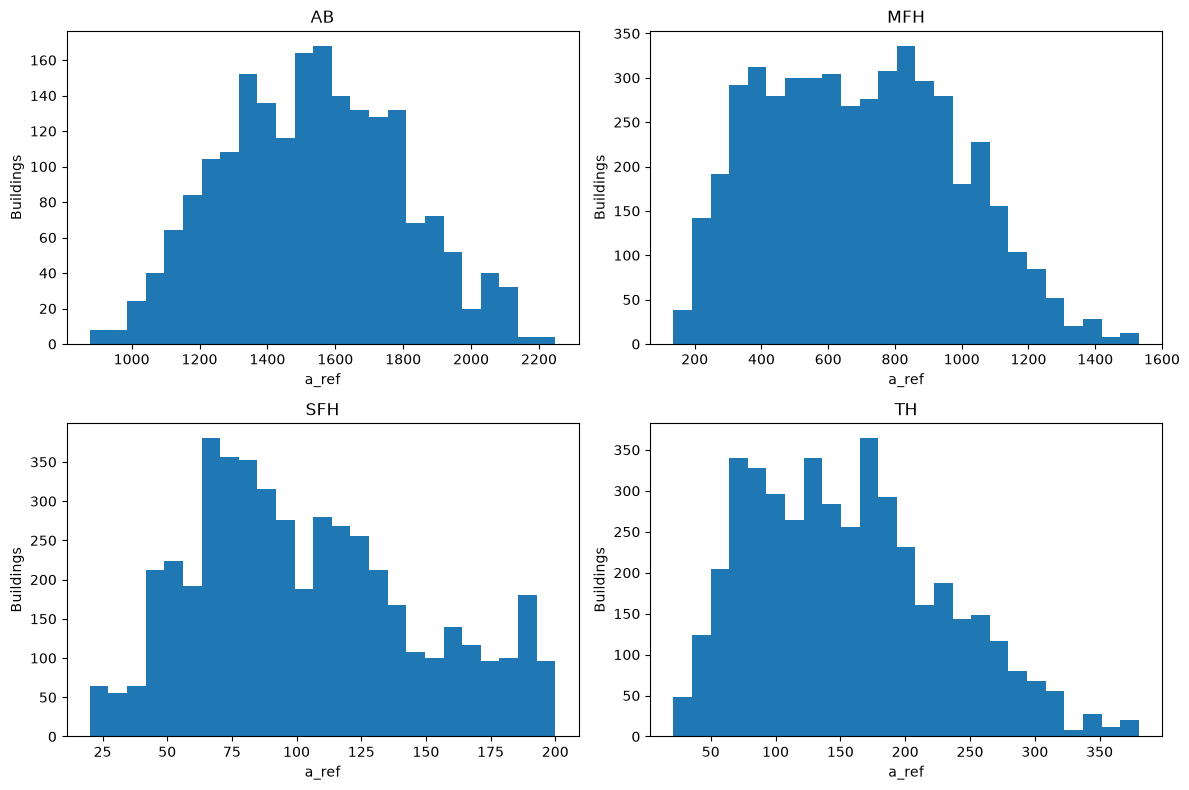

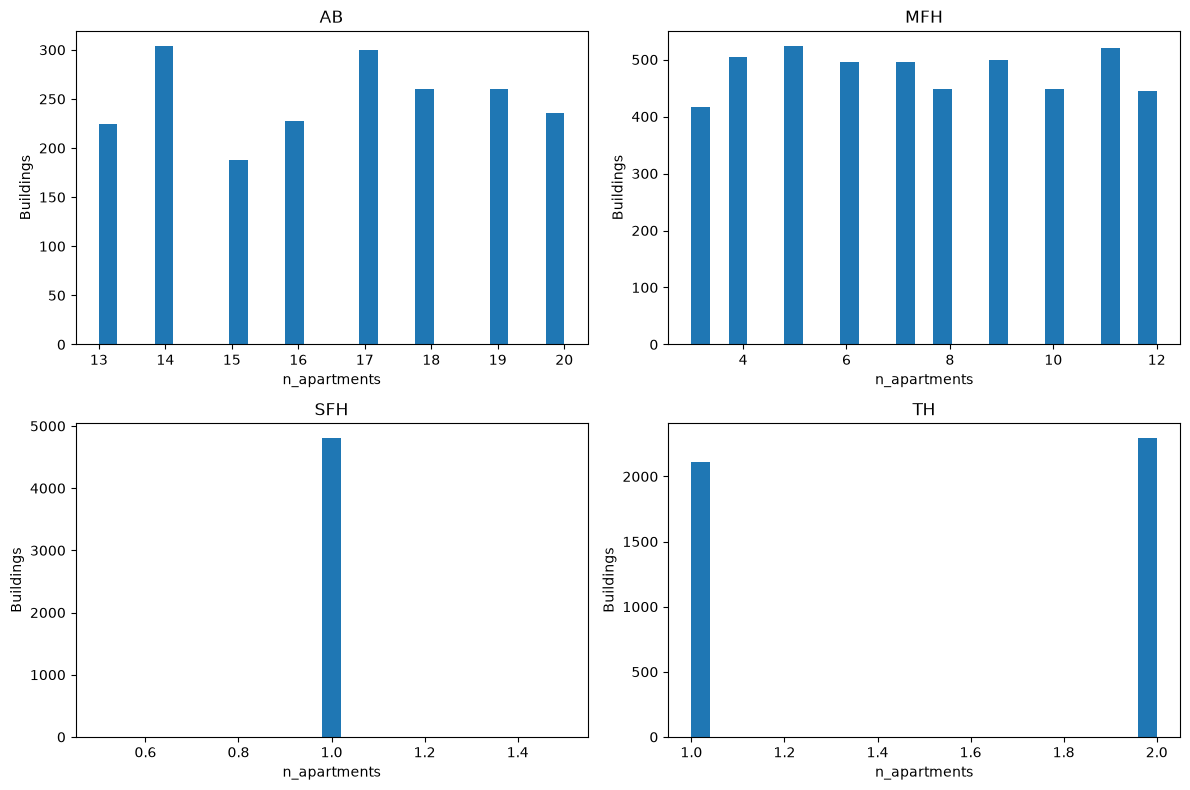

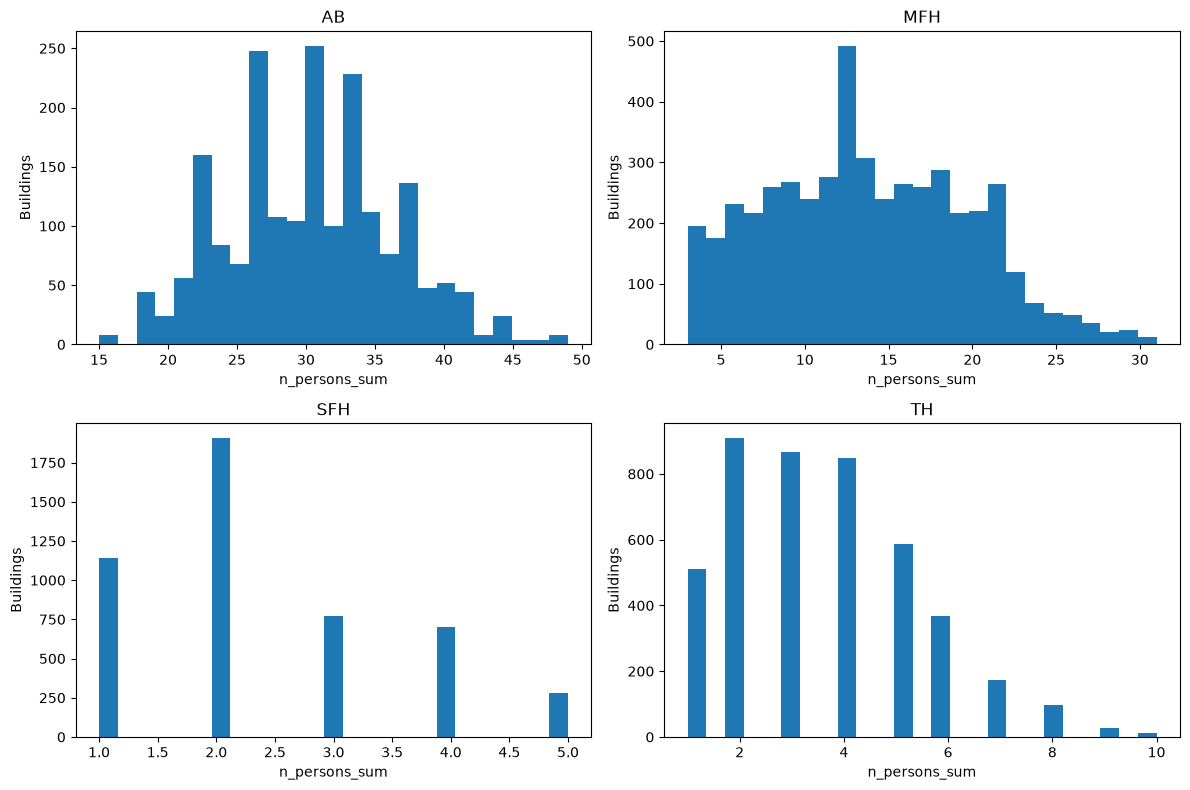

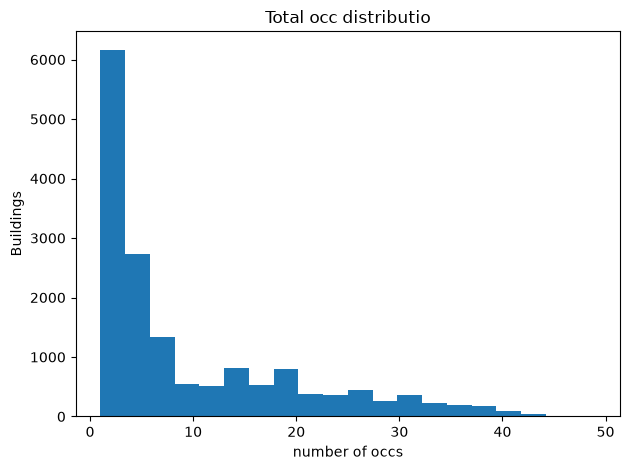

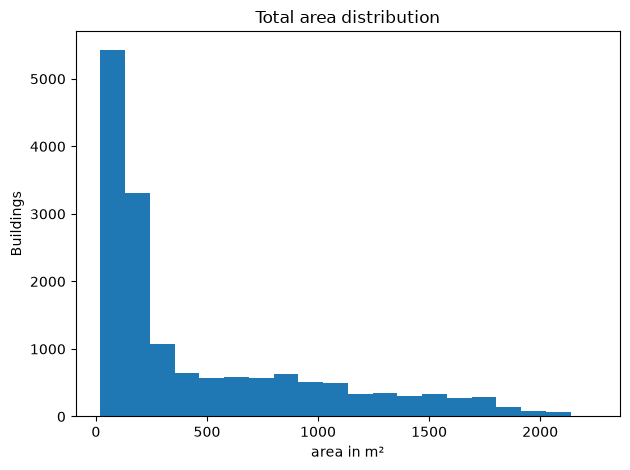

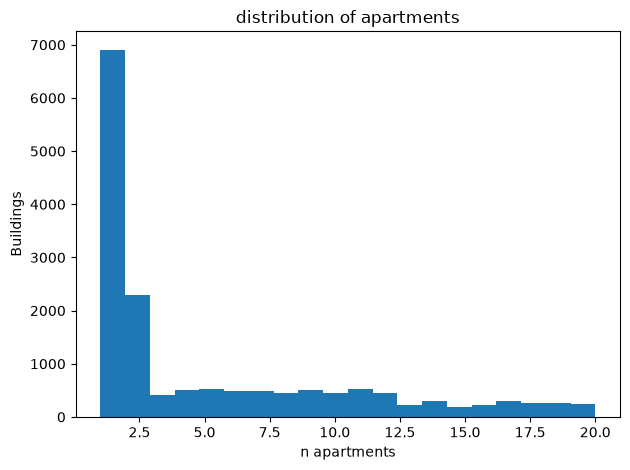

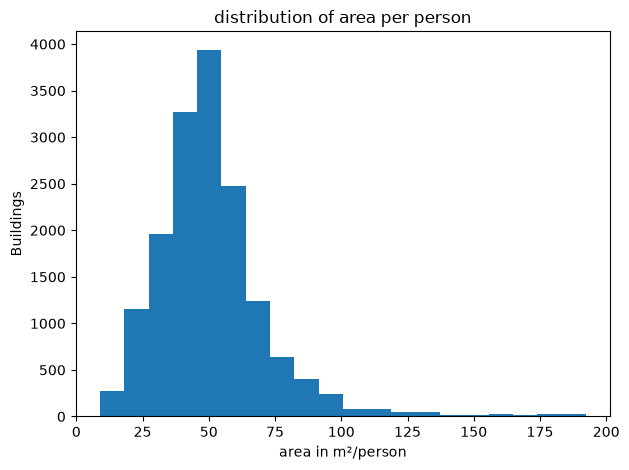

overview realized================================================================================
Overview
Rows: 15,996
Unique areas (a_ref): 2,998
Unique buildings: 4,000
Unique runs: 15,996
MISSING VALUES
country                   0
buildingType              0
surrounding               0
buildingAgeBin            0
a_ref                     0
n_apartments              0
year_type                 0
future                    0
climateRegion             0
n_persons                 0
freq                      0
hasFirePlace              0
varyoccupancy             0
mean_load                 0
nightReduction            0
capControl                0
occControl                0
comfortT_lb               0
comfortT_ub               0
cores                     0
useCache                  0
year                      0
seed                      0
weatherFilepath           0
weatherID                 0
resolved_climateRegion    0
resolved_latitude         0
resolved_longitude        0
state_see

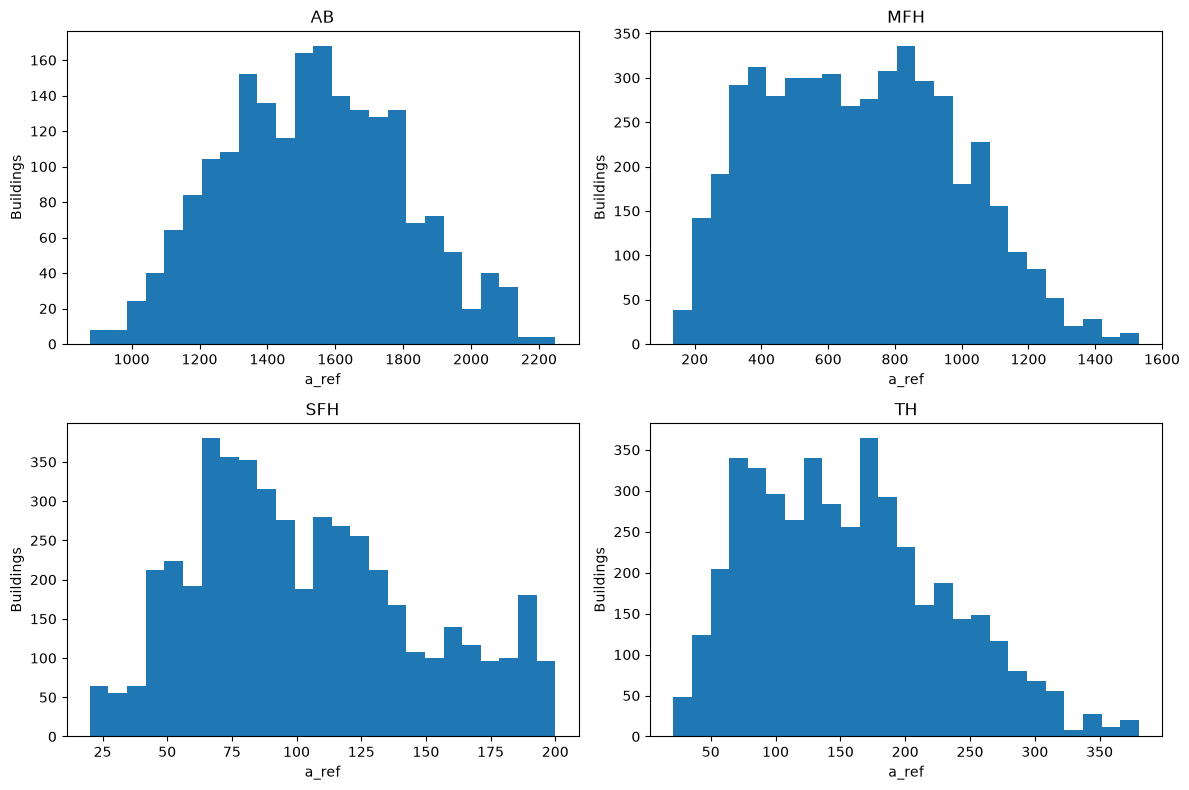

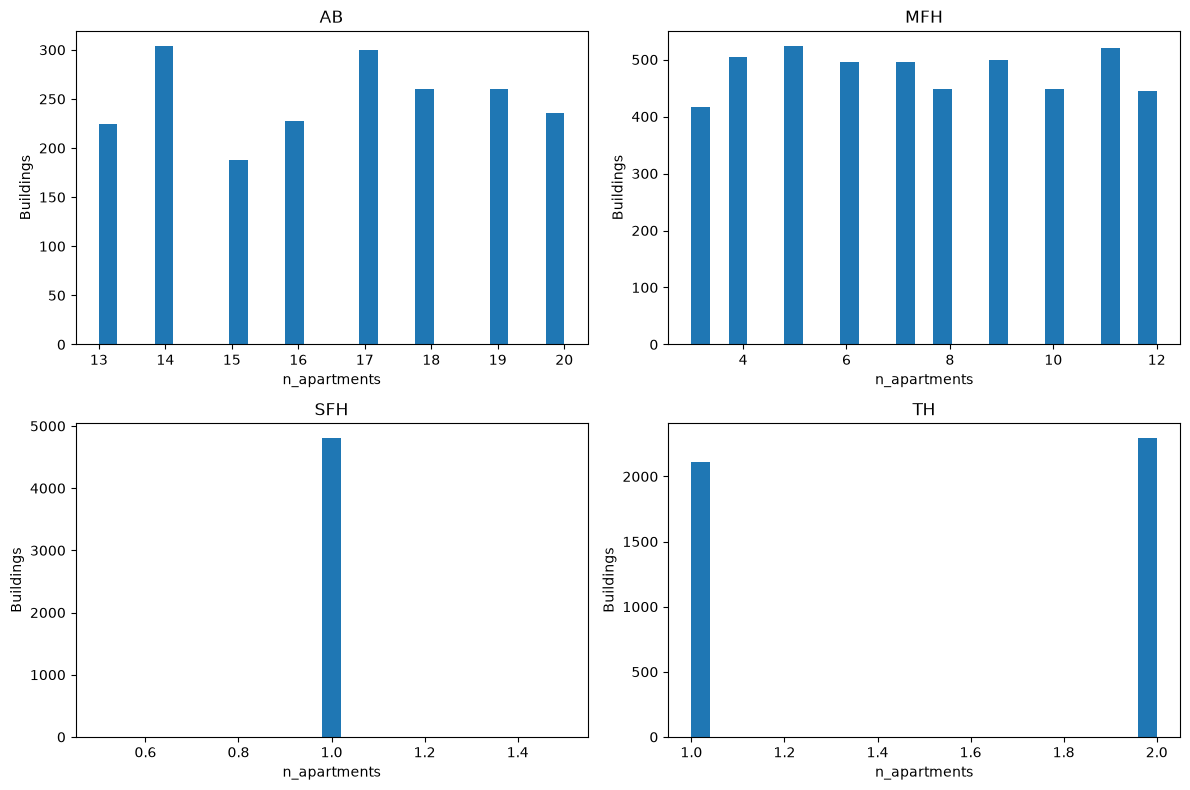

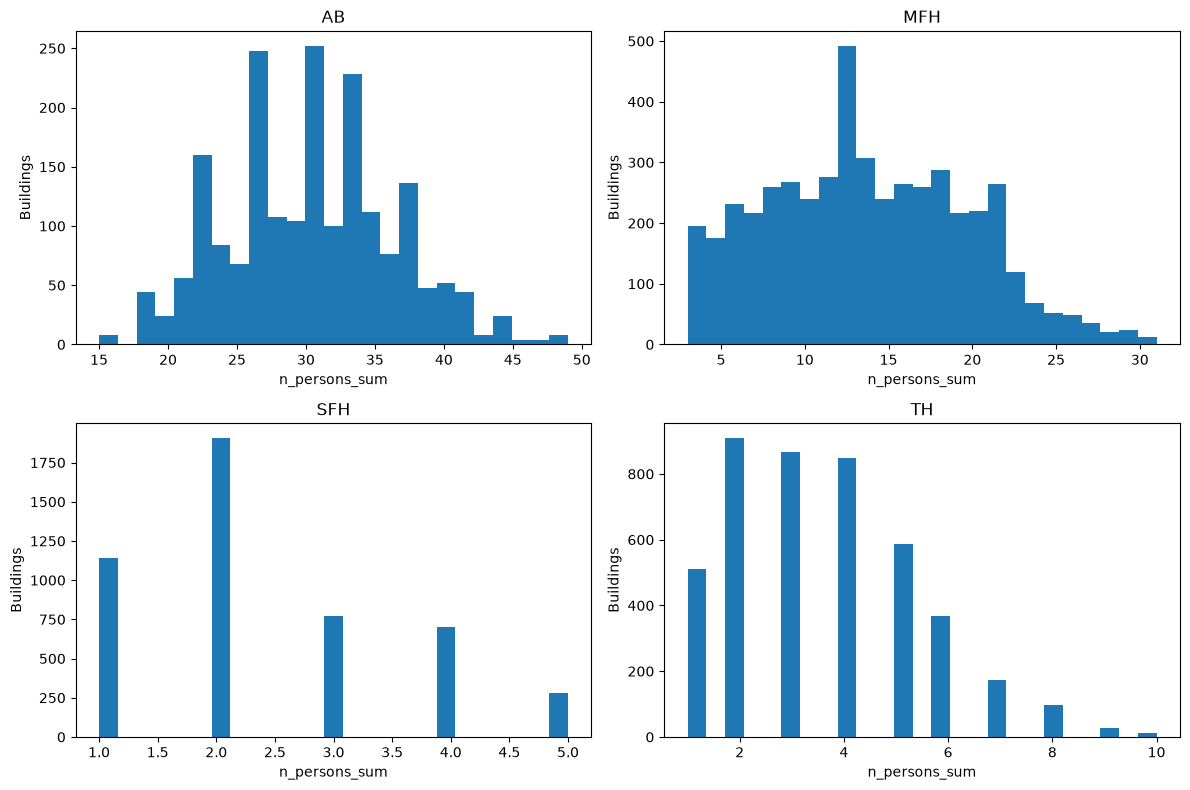

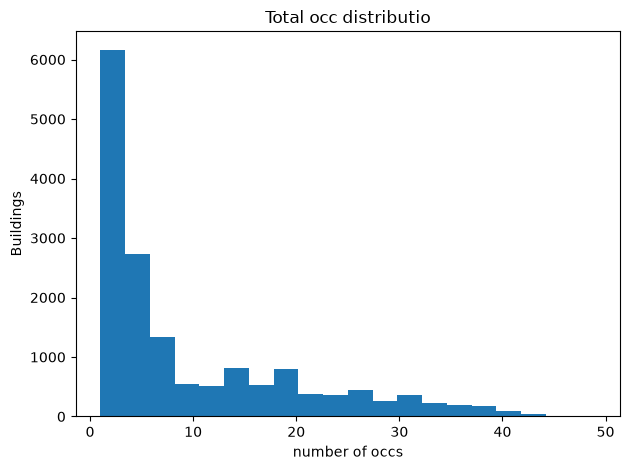

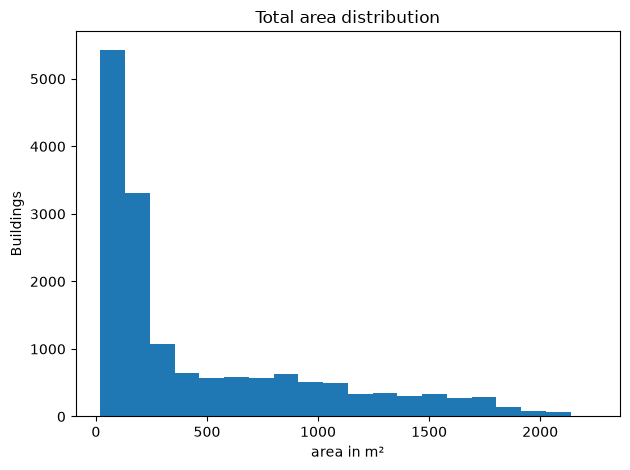

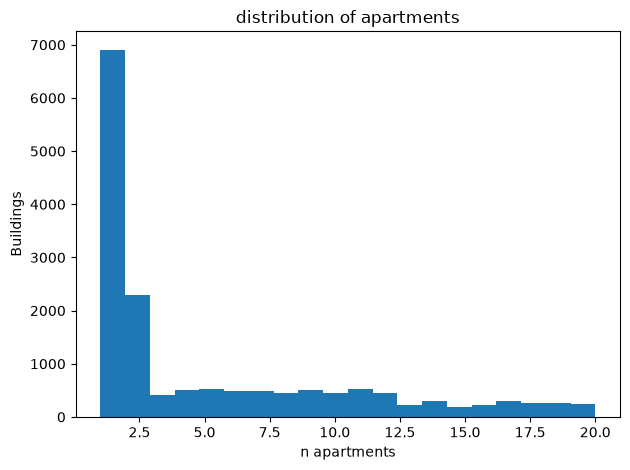

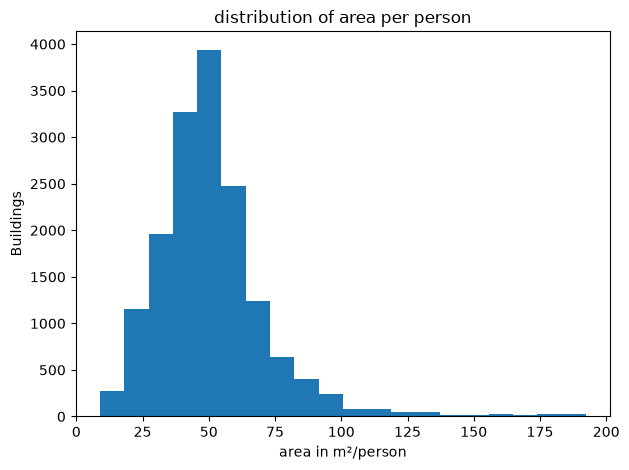

year_type  future  weatherID                                  
average    False   TRY2015_1_average_TRY2015_533096080207_Jahr    0.100000
                   TRY2015_1_average_TRY2015_532217077767_Jahr    0.081250
                   TRY2015_1_average_TRY2015_535407086034_Jahr    0.075000
                   TRY2015_1_average_TRY2015_539647092989_Jahr    0.075000
                   TRY2015_1_average_TRY2015_545100089230_Jahr    0.062500
                                                                    ...   
hot        True    TRY2045_1_hot_TRY2045_539997089829_Somm        0.057292
                   TRY2045_1_hot_TRY2045_536599098044_Somm        0.052083
                   TRY2045_1_hot_TRY2045_539647092989_Somm        0.046875
                   TRY2045_1_hot_TRY2045_535407086034_Somm        0.036458
                   TRY2045_1_hot_TRY2045_545100089230_Somm        0.036458
Name: proportion, Length: 96, dtype: float64
year_type  future  weatherID                                  
aver

In [7]:
comp_manifests(planned_manifest, realized_manifest)

In [22]:
check_duplicate_timeseries(realized_manifest)

Duplicated Seed Lists: True
Duplicated Seeds: <ArrowStringArray>
['[2374420]', '[6276708]', '[6070954]']
Length: 3, dtype: str


In [23]:
ts_res = check_timeseries(RESULTS_DIR)

Checking timeseries:   0%|          | 0/303 [00:00<?, ?run/s]

In [24]:
ts_res


,run_id,nan_vals,neg_load_vals,total_persons,a_ref,elec_sum_yearly,elec_sum_yearly_per_occ,elec_sum_yearly_per_a_ref,elec_max,elec_min,...,temperature_p05,temperature_p95,buildingType,buildingAgeBin,surrounding,climateRegion,year_type,future,seed,state_seed
0,run_006397,False,False,2,86.4,2500.876709,1250.438354,28.945332,5.624760,0.035853,...,0.500000,23.879999,SFH,DE.01,Detached,1,hot,True,1006397,1006397
1,run_006398,False,False,2,86.4,2890.143311,1445.071655,33.450733,8.029754,0.042682,...,1.800000,21.440001,SFH,DE.01,Detached,1,hot,True,1006398,1006398
2,run_006399,False,False,2,104.9,2291.400879,1145.700439,21.843668,6.189282,0.046097,...,-7.130000,21.740000,SFH,DE.01,Detached,10,cold,False,1006399,1006399
3,run_006400,False,False,2,104.9,3633.571777,1816.785889,34.638435,7.716148,0.047804,...,-6.600000,22.799999,SFH,DE.01,Detached,10,cold,False,1006400,1006400
4,run_006401,False,False,2,104.9,3313.309082,1656.654541,31.585405,8.074320,0.046097,...,-7.575000,21.646751,SFH,DE.01,Detached,10,cold,False,1006401,1006401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,run_006695,False,False,4,82.4,3275.431396,818.857849,39.750381,7.260596,0.040975,...,-0.200000,22.900000,SFH,DE.02,Detached,5,cold,True,1006695,1006695
299,run_006696,False,False,1,131.8,1947.676880,1947.676880,14.777517,7.480619,0.039268,...,-2.770000,23.325001,SFH,DE.02,Detached,4,cold,True,1006696,1006696
300,run_006697,False,False,1,131.8,1687.879517,1687.879517,12.806370,4.640358,0.040975,...,-2.770000,23.325001,SFH,DE.02,Detached,4,cold,True,1006697,1006697
301,run_006698,False,False,1,131.8,2324.243408,2324.243408,17.634623,8.566254,0.040975,...,-2.558333,24.725000,SFH,DE.02,Detached,4,cold,True,1006698,1006698


In [ ]:
ts_res.to_parquet(
    RESULTS_DIR / "timeseries_summary.parquet",
    index=False,
)